In [127]:
import pandas as pd
import numpy as np
import yfinance as yf

In [128]:
data=yf.download('AAPL',start='2024-01-01')

[*********************100%***********************]  1 of 1 completed


In [130]:
data.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-08-10,308.260010,308.260010,304.609985,306.829987,44812500
2026-08-11,304.910004,309.970001,302.790009,307.750000,37476700
2026-08-12,302.250000,305.660004,300.570007,305.100006,41657800
2026-08-13,305.260010,306.000000,302.049988,304.209991,40349300
2026-08-14,305.929993,307.489990,304.299988,306.000000,28186700


In [131]:
# pip install prophet

In [132]:
# Prophet doesn't automatically know that:
# Date → time
# Close → target
# Instead, Prophet's Python API defines its expected schema as:
# ds → datestamp
# y  → observed value
# df = df.rename(
#     columns={
#         "Date": "ds",
#         "Close": "y"
#     }
# )

In [133]:
data.shape

(657, 5)

In [134]:
data.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [135]:
data.columns

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

In [136]:
y=data['Close']

In [137]:
import matplotlib.pyplot as plt

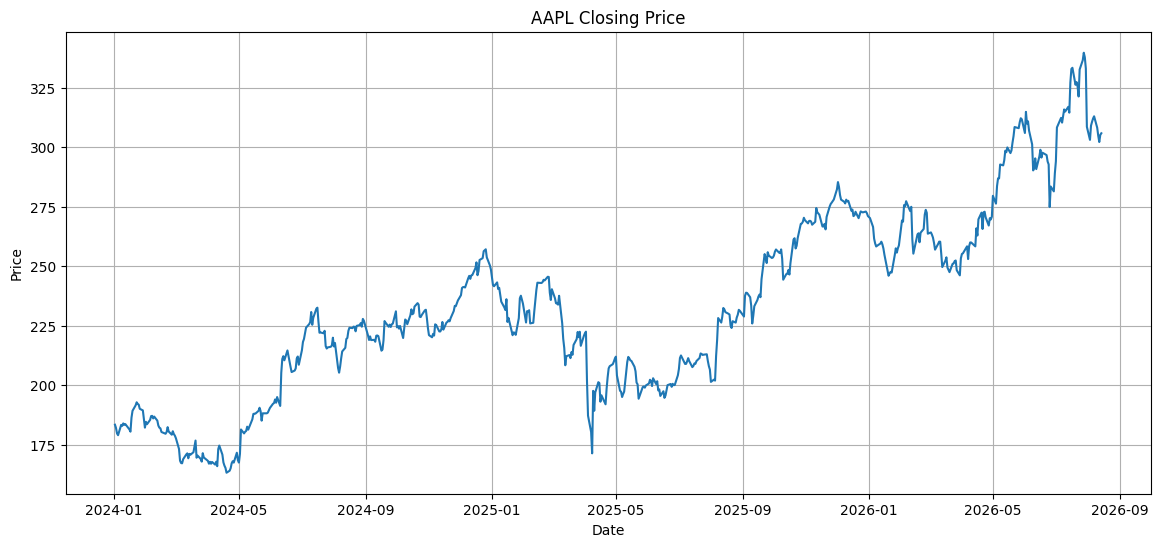

In [138]:
plt.figure(figsize=(14, 6))

plt.plot(data["Close"])

plt.title("AAPL Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

In [139]:
df=data[["Close"]].copy()

In [140]:
df

Price,Close
Ticker,AAPL
Date,
2024-01-02,183.404022
2024-01-03,182.030746
2024-01-04,179.718948
2024-01-05,178.997711
2024-01-08,183.324982
...,...
2026-08-10,308.260010
2026-08-11,304.910004


In [141]:
df1 = data[["Close"]].reset_index()

In [142]:
df1

Price,Date,Close
Ticker,,AAPL
0,2024-01-02,183.404022
1,2024-01-03,182.030746
2,2024-01-04,179.718948
3,2024-01-05,178.997711
4,2024-01-08,183.324982
...,...,...
652,2026-08-10,308.260010
653,2026-08-11,304.910004
654,2026-08-12,302.250000


In [144]:
prophet_df = pd.DataFrame({
    "ds": df1["Date"].copy(),
    "y": df1["Close"]["AAPL"].copy()
})

In [145]:
prophet_df.head()

,ds,y
0,2024-01-02,183.404022
1,2024-01-03,182.030746
2,2024-01-04,179.718948
3,2024-01-05,178.997711
4,2024-01-08,183.324982


In [146]:
prophet_df["ds"] = pd.to_datetime(prophet_df["ds"])

In [147]:
prophet_df.head()

,ds,y
0,2024-01-02,183.404022
1,2024-01-03,182.030746
2,2024-01-04,179.718948
3,2024-01-05,178.997711
4,2024-01-08,183.324982


In [148]:
print(prophet_df.dtypes)

ds    datetime64[ns]
y            float64
dtype: object


In [149]:
from sklearn.model_selection import train_test_split

In [150]:
split_date = "2026-01-01"

train = prophet_df[prophet_df["ds"] < split_date].copy()
test = prophet_df[prophet_df["ds"] >= split_date].copy()

In [151]:
train

,ds,y
0,2024-01-02,183.404022
1,2024-01-03,182.030746
2,2024-01-04,179.718948
3,2024-01-05,178.997711
4,2024-01-08,183.324982
...,...,...
497,2025-12-24,273.066711
498,2025-12-26,272.657806
499,2025-12-29,273.016876
500,2025-12-30,272.338684


In [152]:
test

,ds,y
502,2026-01-02,270.274323
503,2026-01-05,266.534515
504,2026-01-06,261.647797
505,2026-01-07,259.623291
506,2026-01-08,258.336823
...,...,...
652,2026-08-10,308.260010
653,2026-08-11,304.910004
654,2026-08-12,302.250000
655,2026-08-13,305.260010


In [153]:
from prophet import Prophet


In [154]:
# Prophet(
#     growth="linear",
#     changepoints=None,
#     n_changepoints=25,
#     changepoint_range=0.8,
#     yearly_seasonality="auto",
#     weekly_seasonality="auto",
#     daily_seasonality="auto",
#     seasonality_mode="additive",
#     seasonality_prior_scale=10,
#     holidays_prior_scale=10,
#     changepoint_prior_scale=0.05,
#     interval_width=0.80,
#     uncertainty_samples=1000,
#     mcmc_samples=0
# )

# growth="linear"----The trend is allowed to change its slope at changepoints.

# growth="flat"------which assumes essentially no trend growth.

# n_changepoints=25,etc...----This determines the number of potential changepoints.Give the model 50 potential locations where the trend could change.

# changepoint_range=0.8------This means potential changepoints are placed within roughly the first 80% of the training history.

# Why not the last 20%?
# Because otherwise the model could start treating very recent random movements as permanent trend changes.
# model = Prophet(
#     changepoint_range=0.9
# )

# allows potential changepoints through 90% of the history.

# Prophet documents this specifically as a way to give the model more ability to capture recent trend changes.

In [155]:
# Prophet(
#     changepoint_prior_scale=0.5  Allow the trend to adapt much more strongly.
#     changepoint_prior_scale=0.01--Don't allow the trend to change too easily.
# )



In [156]:
# 20. Seasonality
# Prophet can model recurring patterns.
# weekly_seasonality=True,False
# yearly_seasonality=True,False
# Daily_seasonality=False,True
# Because you have one observation per trading day, not observations every hour/minute.

# Daily seasonality is much more relevant for intraday data.

# Prophet automatically handles sub-daily timestamps and can automatically fit daily seasonality for sub-daily observations

In [157]:
# seasonality_mode="additive","multiplicative"


In [158]:
# seasonality_prior_scale--Low        seasonality_prior_scale=1 stronger regularization.
#  ↓
# smooth/simple seasonality            seasonality_prior_scale=20 more flexible seasonality.
#  ↓
# High                                 seasonality_prior_scale=10 This controls how strongly the seasonal component can fit the data.
#  ↓
# complex seasonality

In [159]:
# holidays_prior_scale---This controls the flexibility of holiday effects.
    

In [160]:
# interval_width---yhat , yhat_lower, yhat_upper
# interval_width=0.80  meaning an 80% interval.
# interval_width=0.95   for a wider interval.
    

In [161]:
# uncertainty_samples=1000 This controls how many simulated samples are used for uncertainty estimation
#  mcmc_samples
# mcmc_samples=0 Prophet normally uses MAP estimation.
# mcmc_samples=300  you ask Prophet to perform Bayesian posterior sampling.

In [162]:
# future = model.make_future_dataframe(
#     periods=len(test),
#     freq="B" B means business-day frequency.
# )
# future = test[["ds"]].copy()
# forecast = model.predict(future)
# Prophet returns a dataframe containing many columns
# forecast[
#     [
#         "ds",
#         "yhat",is your predicted AAPL price.
#         "yhat_lower",
#         "yhat_upper"
#     ]
# ]

In [163]:
#  What is Fourier order?
# yearly_seasonality=10,20....
# This controls the complexity of the Fourier representation of the yearly seasonal curve.
# Prophet uses Fourier series to represent seasonality. Higher Fourier order allows more complicated seasonal shapes
# but increases the possibility of overfitting.
    

In [164]:
# add_seasonality()  You aren't limited to Prophet's built-in seasonalities.
# model.add_seasonality(
#     name="quarterly",
#     period=91.25,
#     fourier_order=5
# )


In [165]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.dates as mdates


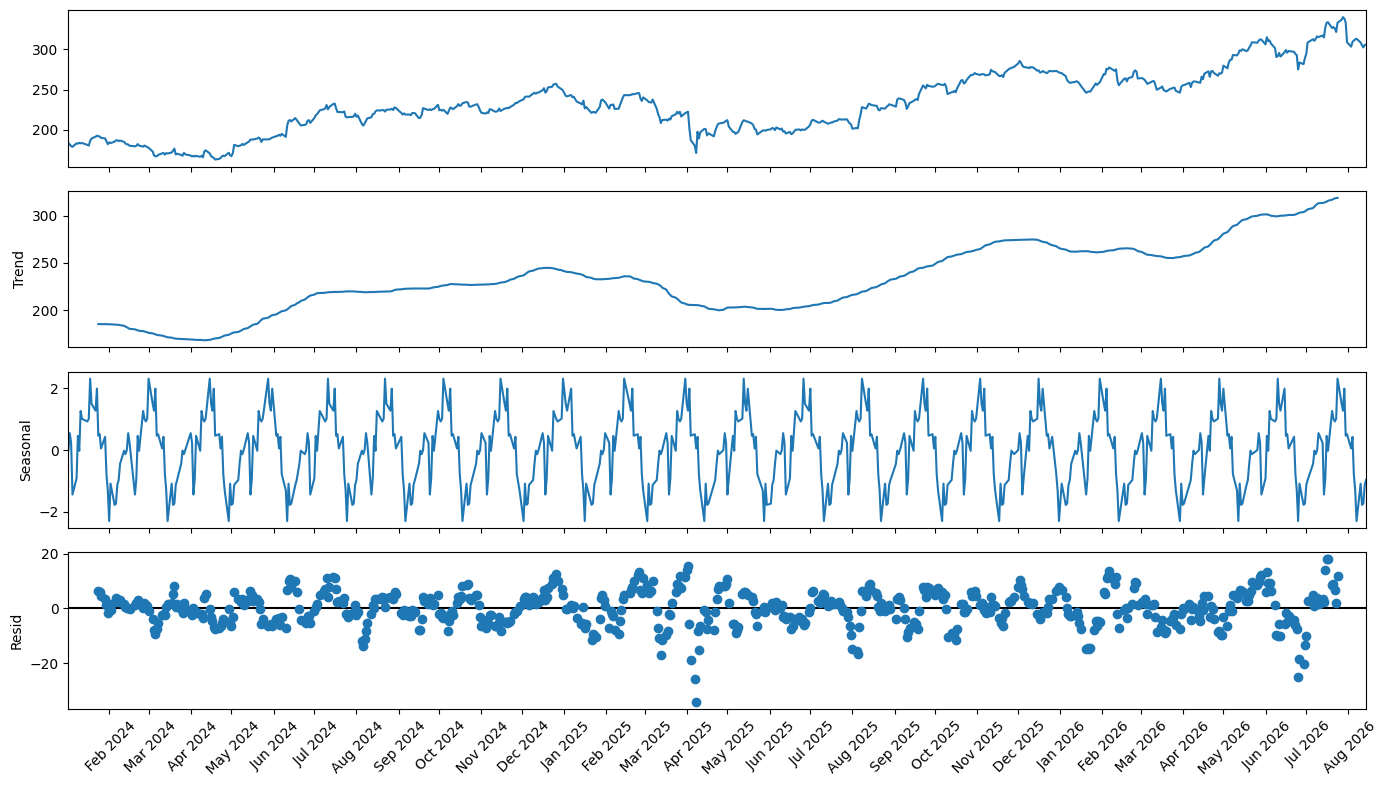

In [166]:
result = seasonal_decompose(df["Close"],model="additive",period=30)
fig = result.plot()
fig.set_size_inches(14, 8)
# Format the dates
for ax in fig.axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter(" %b %Y"))
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [167]:
model = Prophet(
    growth="linear",
    yearly_seasonality='auto',
    weekly_seasonality='auto',
    daily_seasonality='auto',
    seasonality_mode="additive",
    changepoint_prior_scale=0.05,
    changepoint_range=0.8,
    seasonality_prior_scale=10,
    interval_width=0.95
)

In [168]:
train.shape

(502, 2)

In [169]:
train.head()

,ds,y
0,2024-01-02,183.404022
1,2024-01-03,182.030746
2,2024-01-04,179.718948
3,2024-01-05,178.997711
4,2024-01-08,183.324982


In [170]:
model.fit(train)

17:37:37 - cmdstanpy - INFO - Chain [1] start processing
17:37:38 - cmdstanpy - INFO - Chain [1] done processing


In [171]:
future = test[["ds"]].copy()

In [172]:
forecast = model.predict(future)

In [173]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2026-01-02,287.793018,273.955139,303.546462,287.793018,287.803983,0.832739,0.832739,0.832739,0.832739,0.832739,0.832739,0.0,0.0,0.0,288.625757
1,2026-01-05,289.149159,274.960280,305.117695,289.087768,289.260986,0.591706,0.591706,0.591706,0.591706,0.591706,0.591706,0.0,0.0,0.0,289.740865
2,2026-01-06,289.601207,275.163851,306.407193,289.436397,289.890506,0.739887,0.739887,0.739887,0.739887,0.739887,0.739887,0.0,0.0,0.0,290.341093
3,2026-01-07,290.053254,277.065053,305.094019,289.713372,290.526442,0.501947,0.501947,0.501947,0.501947,0.501947,0.501947,0.0,0.0,0.0,290.555200
4,2026-01-08,290.505301,277.079744,306.400640,289.937265,291.140778,0.688735,0.688735,0.688735,0.688735,0.688735,0.688735,0.0,0.0,0.0,291.194036


In [174]:
forecast.shape

(155, 16)

In [175]:
results = test.merge(
    forecast[
        ["ds", "yhat", "yhat_lower", "yhat_upper"]
    ],
    on="ds"
)

In [176]:
results

,ds,y,yhat,yhat_lower,yhat_upper
0,2026-01-02,270.274323,288.625757,273.955139,303.546462
1,2026-01-05,266.534515,289.740865,274.960280,305.117695
2,2026-01-06,261.647797,290.341093,275.163851,306.407193
3,2026-01-07,259.623291,290.555200,277.065053,305.094019
4,2026-01-08,258.336823,291.194036,277.079744,306.400640
...,...,...,...,...,...
150,2026-08-10,308.260010,387.835092,283.733223,486.304317
151,2026-08-11,304.910004,388.435320,280.842735,486.835806
152,2026-08-12,302.250000,388.649427,284.959850,490.952499
153,2026-08-13,305.260010,389.288263,278.934134,488.495927


In [177]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    results["y"],
    results["yhat"]
)

print("MAE:", mae)

MAE: 57.527218823794875


In [178]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        results["y"],
        results["yhat"]
    )
)

print("RMSE:", rmse)

RMSE: 59.655527639090906


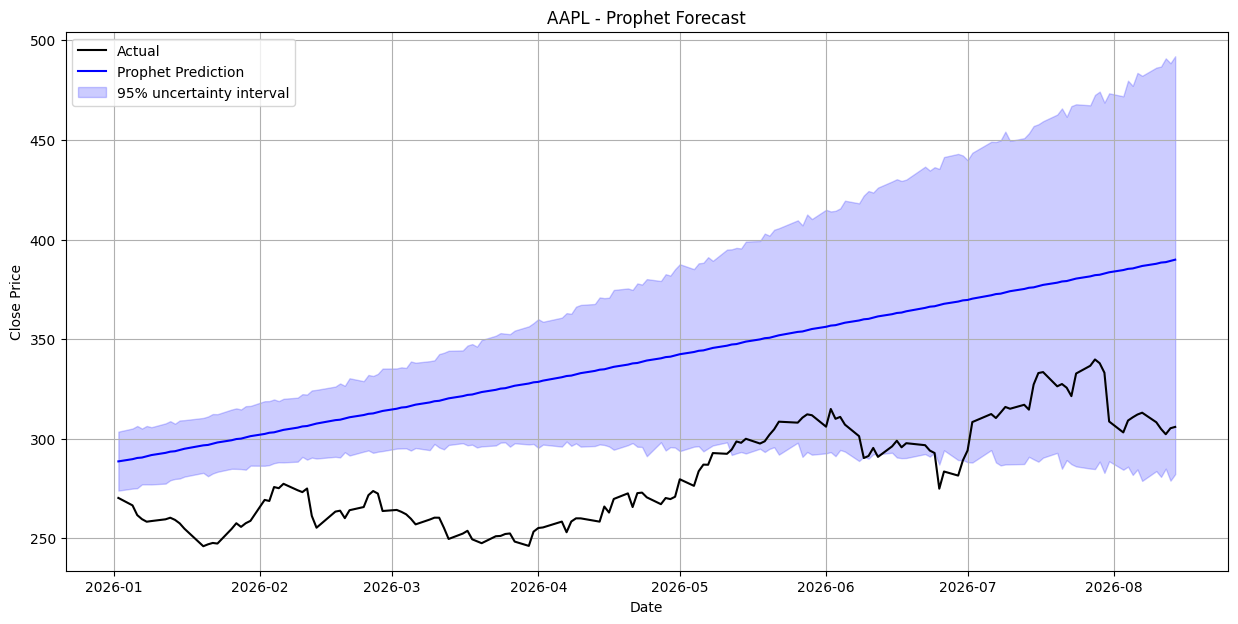

In [179]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))

plt.plot(results["ds"],results["y"],label="Actual",color="black" )

plt.plot(results["ds"],results["yhat"],label="Prophet Prediction",color="blue")

plt.fill_between(results["ds"],results["yhat_lower"],results["yhat_upper"],color="blue",alpha=0.2,label="95% uncertainty interval")

plt.title("AAPL - Prophet Forecast")

plt.xlabel("Date")
plt.ylabel("Close Price")

plt.legend()
plt.grid(True)

plt.show()


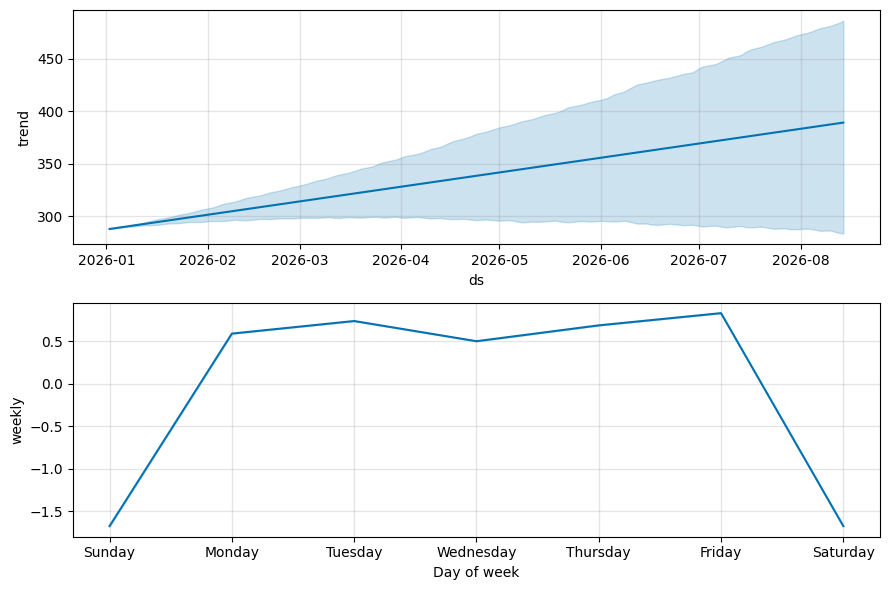

In [180]:
model.plot_components(forecast)

plt.show()

In [107]:
future = model.make_future_dataframe(
    periods=30,
    freq="D"
)

In [108]:
future

,ds
0,2024-01-02
1,2024-01-03
2,2024-01-04
3,2024-01-05
4,2024-01-08
...,...
527,2026-01-26
528,2026-01-27
529,2026-01-28
530,2026-01-29


In [109]:
forecast = model.predict(future)

In [110]:
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
527,2026-01-26,298.453171,284.437320,312.921818,293.902903,303.249862,0.697194,0.697194,0.697194,0.697194,0.697194,0.697194,0.0,0.0,0.0,299.150365
528,2026-01-27,298.904179,285.539004,314.984771,294.150590,304.061974,0.840733,0.840733,0.840733,0.840733,0.840733,0.840733,0.0,0.0,0.0,299.744912
529,2026-01-28,299.355187,283.670637,315.254468,294.130814,304.919930,0.605125,0.605125,0.605125,0.605125,0.605125,0.605125,0.0,0.0,0.0,299.960313
530,2026-01-29,299.806196,284.744972,316.493647,294.277753,305.626526,0.792723,0.792723,0.792723,0.792723,0.792723,0.792723,0.0,0.0,0.0,300.598919
531,2026-01-30,300.257204,284.772933,315.754773,294.357960,306.333122,0.930600,0.930600,0.930600,0.930600,0.930600,0.930600,0.0,0.0,0.0,301.187804


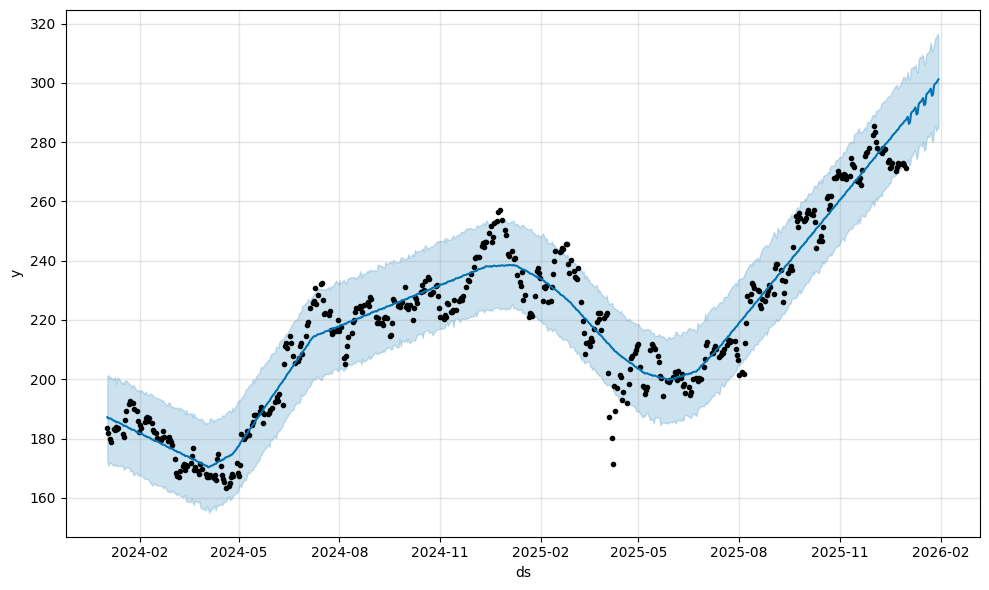

In [111]:
fig = model.plot(forecast)

plt.show()

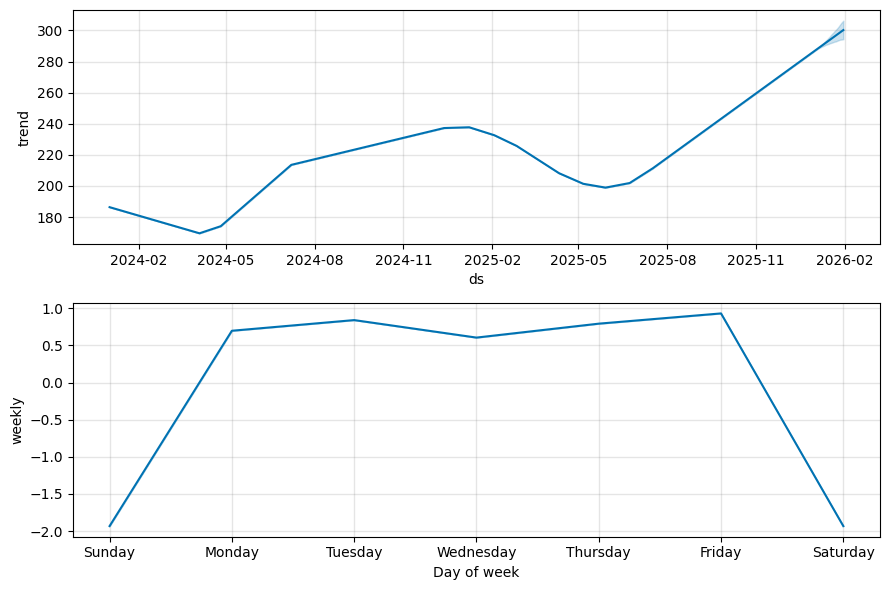

In [112]:
fig = model.plot_components(forecast)

plt.show()

In [115]:
last_date = train["ds"].iloc[-1]
last_date


Timestamp('2025-12-31 00:00:00')

In [182]:
final_train = pd.concat(
    [train, test],
    ignore_index=True
)

final_train = final_train.sort_values("ds").reset_index(drop=True)

print(final_train["ds"].min())
print(final_train["ds"].max())

2024-01-02 00:00:00
2026-08-14 00:00:00


In [183]:
from prophet import Prophet

final_model = Prophet(
    growth="linear",
    yearly_seasonality="auto",
    weekly_seasonality="auto",
    daily_seasonality="auto",

    seasonality_mode="additive",

    changepoint_prior_scale=0.05,
    changepoint_range=0.8,
    seasonality_prior_scale=10,

    interval_width=0.95
)

In [184]:
final_model.fit(final_train)

17:38:40 - cmdstanpy - INFO - Chain [1] start processing
17:38:40 - cmdstanpy - INFO - Chain [1] done processing


In [185]:
last_date=final_train['ds'].iloc[-1]
last_date

Timestamp('2026-08-14 00:00:00')

In [186]:
last_date = final_train["ds"].max()

future_dates = pd.bdate_range(  #bdate_range() means business date range.It generates dates for weekdays (Monday–Friday) rather than every calendar day.
    start=last_date + pd.Timedelta(days=1),
    periods=60
)

future = pd.DataFrame({
    "ds": future_dates
})

print(future.head())
print(future.tail())

          ds
0 2026-08-17
1 2026-08-18
2 2026-08-19
3 2026-08-20
4 2026-08-21
           ds
55 2026-11-02
56 2026-11-03
57 2026-11-04
58 2026-11-05
59 2026-11-06


In [124]:
future_forecast = final_model.predict(future)

In [125]:
future_forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2026-08-17,315.744256,309.499338,336.808907,315.744256,315.744256,7.466877,7.466877,7.466877,0.714840,0.714840,0.714840,6.752036,6.752036,6.752036,0.0,0.0,0.0,323.211132
1,2026-08-18,315.977557,311.018141,337.069800,315.945302,316.018627,8.160658,8.160658,8.160658,0.692817,0.692817,0.692817,7.467841,7.467841,7.467841,0.0,0.0,0.0,324.138215
2,2026-08-19,316.210858,311.517739,338.198458,316.094530,316.315356,8.958759,8.958759,8.958759,0.812768,0.812768,0.812768,8.145992,8.145992,8.145992,0.0,0.0,0.0,325.169618
3,2026-08-20,316.444160,311.923517,338.460613,316.215810,316.682162,9.277613,9.277613,9.277613,0.505875,0.505875,0.505875,8.771739,8.771739,8.771739,0.0,0.0,0.0,325.721773
4,2026-08-21,316.677461,312.829329,340.785326,316.381226,317.027218,9.924099,9.924099,9.924099,0.591933,0.591933,0.591933,9.332166,9.332166,9.332166,0.0,0.0,0.0,326.601560
5,2026-08-24,317.377365,314.437338,342.668595,316.928323,317.919642,11.240520,11.240520,11.240520,0.714840,0.714840,0.714840,10.525680,10.525680,10.525680,0.0,0.0,0.0,328.617885
6,2026-08-25,317.610666,314.738659,341.951629,316.980611,318.342523,11.434224,11.434224,11.434224,0.692817,0.692817,0.692817,10.741406,10.741406,10.741406,0.0,0.0,0.0,329.044890
7,2026-08-26,317.843967,315.999205,343.236648,317.002700,318.800075,11.675639,11.675639,11.675639,0.812768,0.812768,0.812768,10.862872,10.862872,10.862872,0.0,0.0,0.0,329.519607
8,2026-08-27,318.077269,315.043540,343.943164,317.036263,319.222508,11.397965,11.397965,11.397965,0.505875,0.505875,0.505875,10.892090,10.892090,10.892090,0.0,0.0,0.0,329.475234
9,2026-08-28,318.310570,316.515839,343.741057,316.992740,319.672681,11.425508,11.425508,11.425508,0.591933,0.591933,0.591933,10.833574,10.833574,10.833574,0.0,0.0,0.0,329.736078


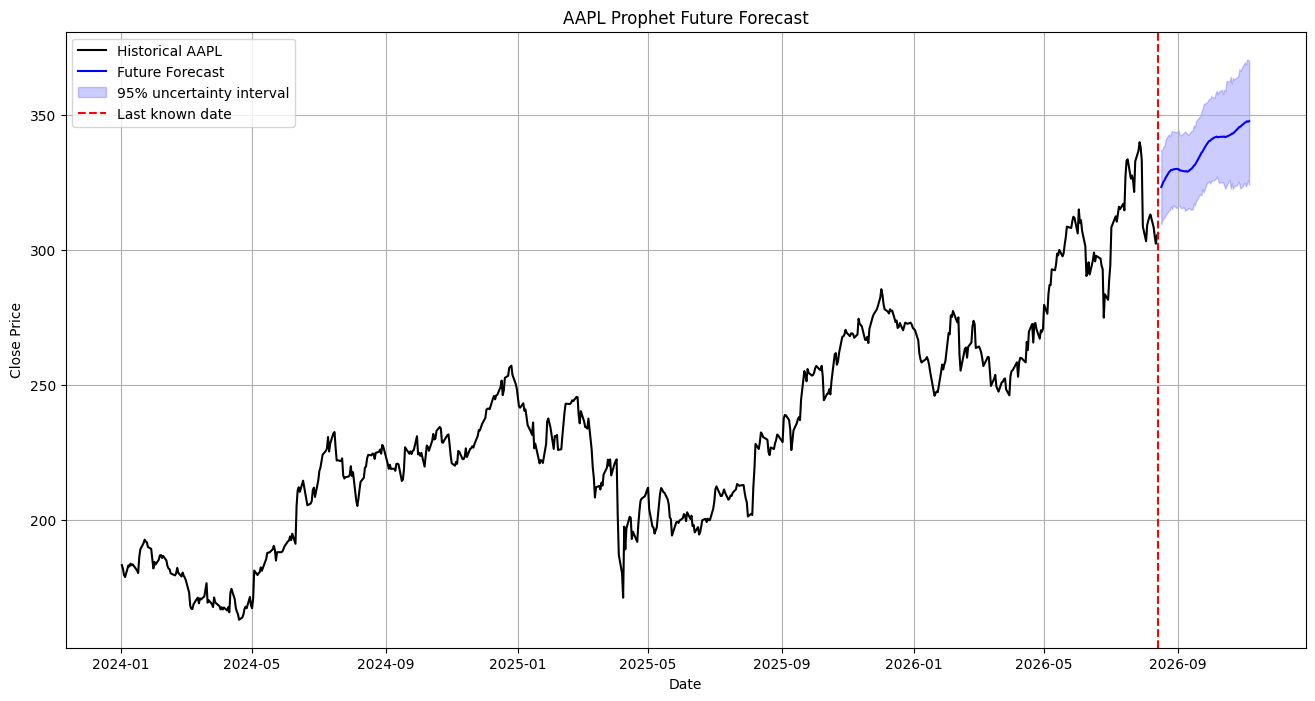

In [126]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))

# Historical actual prices
plt.plot(
    final_train["ds"],
    final_train["y"],
    color="black",
    label="Historical AAPL"
)

# Future forecast
plt.plot(
    future_forecast["ds"],
    future_forecast["yhat"],
    color="blue",
    label="Future Forecast"
)

# Uncertainty interval
plt.fill_between(
    future_forecast["ds"],
    future_forecast["yhat_lower"],
    future_forecast["yhat_upper"],
    color="blue",
    alpha=0.2,
    label="95% uncertainty interval"
)

# Forecast starting point
plt.axvline(
    last_date,
    color="red",
    linestyle="--",
    label="Last known date"
)

plt.title("AAPL Prophet Future Forecast")

plt.xlabel("Date")
plt.ylabel("Close Price")

plt.legend()
plt.grid(True)

plt.show()
